In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
%matplotlib inline
df = pd.read_csv("NHANES Weight and Height.csv")
df

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6
...,...,...,...,...
8383,8383,94.3,178.8,29.5
8384,8384,82.8,147.8,37.9
8385,8385,108.8,168.7,38.2
8386,8386,79.5,176.4,25.5


In [4]:
df.head()

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
0,0,97.1,160.2,37.8
1,1,98.8,182.3,29.7
2,2,74.3,184.2,21.9
3,3,103.7,185.3,30.2
4,4,83.3,177.1,26.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            8388 non-null   int64  
 1   Weight (kg)           8388 non-null   float64
 2   Standing Height (cm)  8388 non-null   float64
 3   BMI(kg/m**2)          8388 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 262.3 KB


In [6]:
df.columns

Index(['Unnamed: 0', 'Weight (kg)', 'Standing Height (cm)', 'BMI(kg/m**2)'], dtype='object')

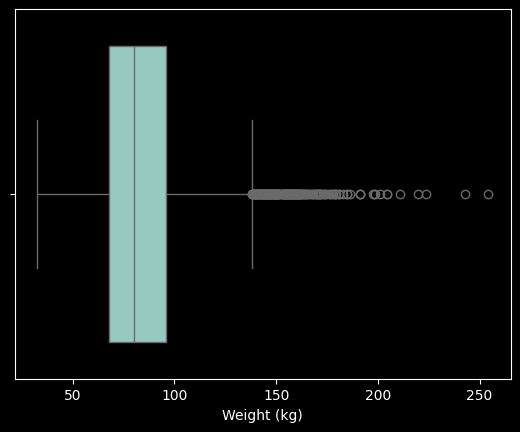

In [7]:
sns.boxplot (data = df, x = "Weight (kg)")
plt.show()

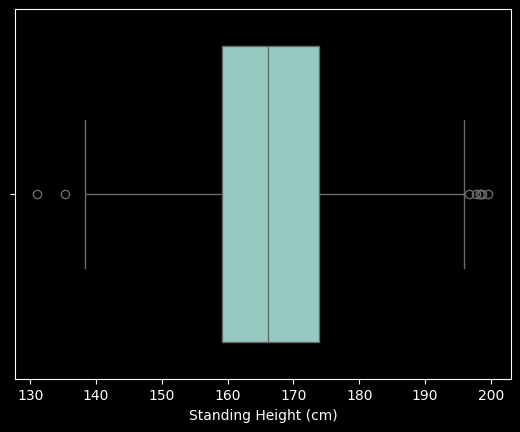

In [8]:
sns.boxplot (data = df, x = "Standing Height (cm)")
plt.show()

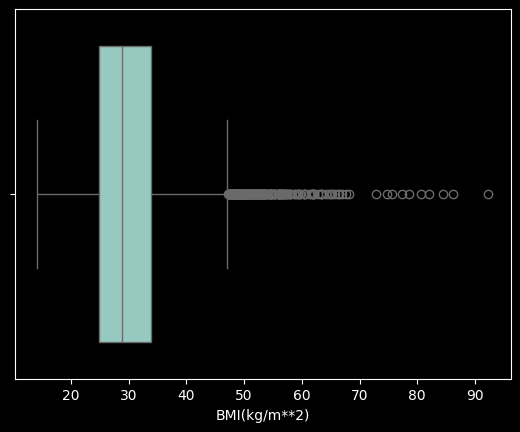

In [9]:

sns.boxplot (data = df, x = "BMI(kg/m**2)")
plt.show()

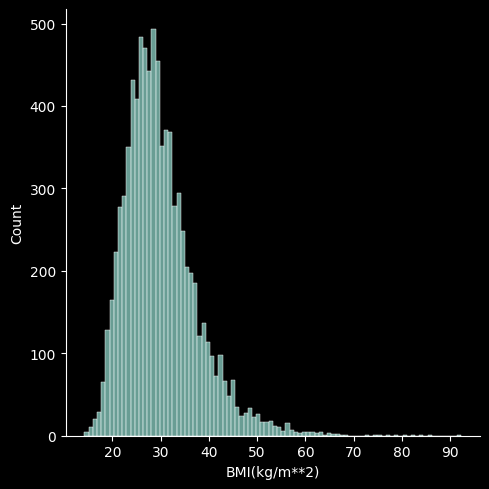

In [10]:

sns.displot (data = df, x = "BMI(kg/m**2)", kind = "hist")
plt.show()

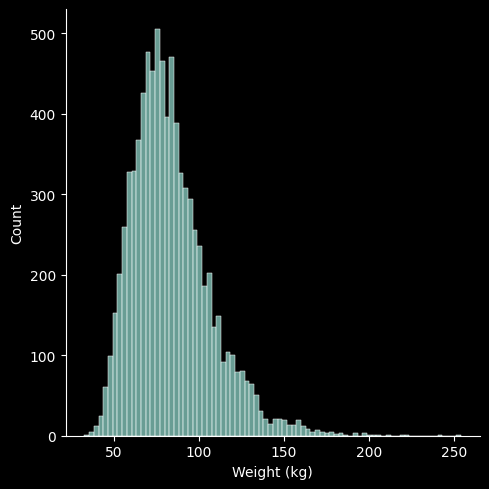

In [11]:
sns.displot (data = df, x = "Weight (kg)", kind = "hist")
plt.show()

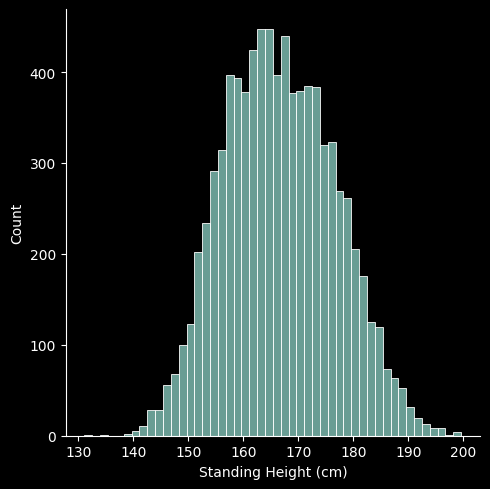

In [12]:
sns.displot (data = df, x = "Standing Height (cm)", kind = "hist")
plt.show()

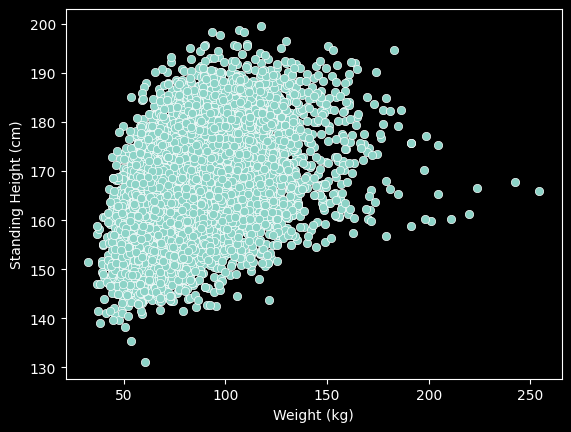

In [13]:
sns.scatterplot (data = df, x = "Weight (kg)", y = "Standing Height (cm)")
plt.show()

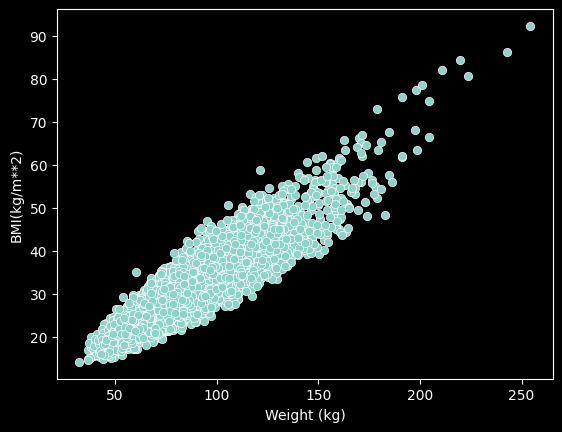

In [14]:
sns.scatterplot (data = df, x = "Weight (kg)", y = "BMI(kg/m**2)")
plt.show()

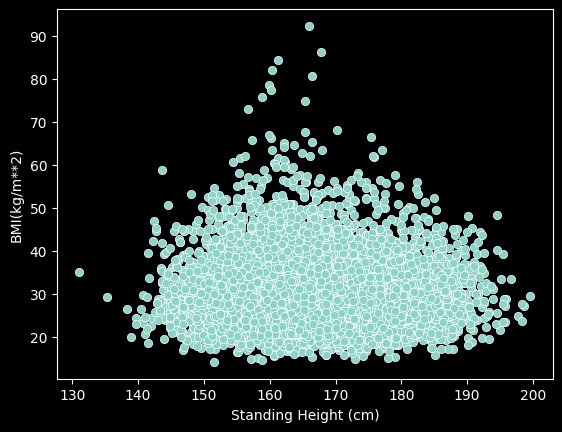

In [15]:
sns.scatterplot (data = df, x = "Standing Height (cm)", y = "BMI(kg/m**2)")
plt.show()

In [16]:
df.skew()

Unnamed: 0              0.000000
Weight (kg)             1.129603
Standing Height (cm)    0.142496
BMI(kg/m**2)            1.353043
dtype: float64

In [17]:
# AS we saw that only the column 'Standing Height' is in the form of narmal distribution 
# so 'Standing Height' can be deal with "Z-SCORE" 

In [18]:
z_score_height = stats.zscore(df["Standing Height (cm)"])
z_score_height

array([-0.63910757,  1.55369806,  1.74221981, ...,  0.20427921,
        0.96828842,  0.08521284], shape=(8388,))

In [19]:
df1 = df.copy()

In [20]:
df1["Z score Height"] = z_score_height

In [21]:
df1

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z score Height
0,0,97.1,160.2,37.8,-0.639108
1,1,98.8,182.3,29.7,1.553698
2,2,74.3,184.2,21.9,1.742220
3,3,103.7,185.3,30.2,1.851364
4,4,83.3,177.1,26.6,1.037744
...,...,...,...,...,...
8383,8383,94.3,178.8,29.5,1.206421
8384,8384,82.8,147.8,37.9,-1.869460
8385,8385,108.8,168.7,38.2,0.204279
8386,8386,79.5,176.4,25.5,0.968288


In [22]:
z_score_weight = stats.zscore(df["Weight (kg)"])
z_score_weight

array([ 0.57965616,  0.65302609, -0.40436401, ...,  1.08461388,
       -0.17993836, -1.03448219], shape=(8388,))

In [23]:
df2 = df.copy()

In [24]:
df2["Z score Weight"] = z_score_weight
df2

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z score Weight
0,0,97.1,160.2,37.8,0.579656
1,1,98.8,182.3,29.7,0.653026
2,2,74.3,184.2,21.9,-0.404364
3,3,103.7,185.3,30.2,0.864504
4,4,83.3,177.1,26.6,-0.015935
...,...,...,...,...,...
8383,8383,94.3,178.8,29.5,0.458812
8384,8384,82.8,147.8,37.9,-0.037514
8385,8385,108.8,168.7,38.2,1.084614
8386,8386,79.5,176.4,25.5,-0.179938


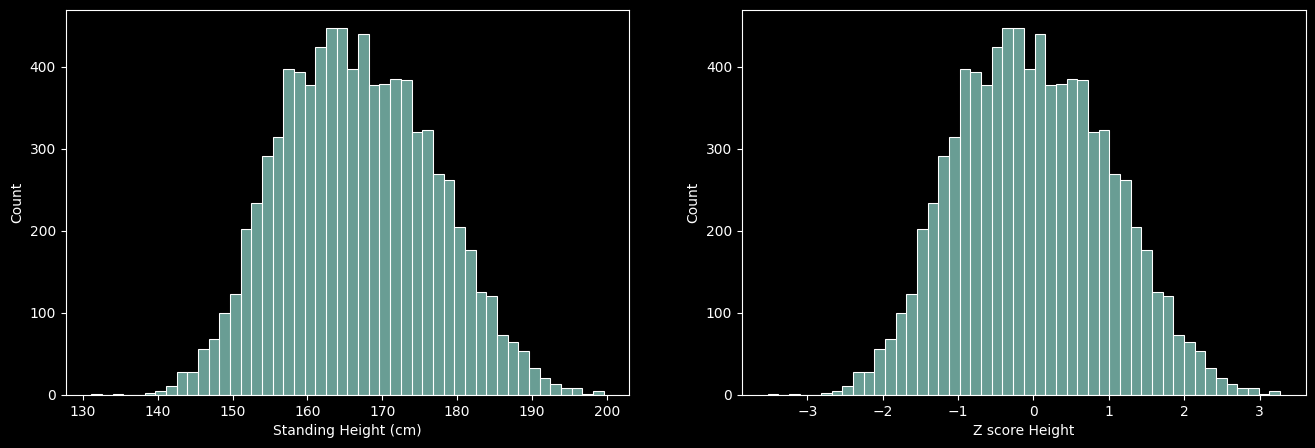

In [25]:
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df1["Standing Height (cm)"])

plt.subplot(1,2,2)
sns.histplot(df1["Z score Height"])
plt.show()

In [26]:
df1[(z_score_height < -3) | (z_score_height > 3)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2),Z score Height
60,60,106.8,198.7,27.1,3.180938
1906,1906,53.8,135.3,29.4,-3.109735
2165,2165,60.3,131.1,35.1,-3.526467
3379,3379,97.5,197.7,24.9,3.081716
4026,4026,93.6,198.4,23.8,3.151172
5815,5815,109.1,198.3,27.7,3.141250
7576,7576,117.4,199.6,29.5,3.270238


In [27]:
'''Now  here "Weight" and "IBM" are not in normal distribution form so they '''
'''can't be handel with Z-SCORE there form we are using IQR form them 
lest see for Weight (kg)'''

"can't be handel with Z-SCORE there form we are using IQR form them \nlest see for Weight (kg)"

In [28]:
x_upper = df["Weight (kg)"].mean() + 3 * df["Weight (kg)"].std()
x_lower = df["Weight (kg)"].mean() - 3 * df["Weight (kg)"].std()
x_lower , x_upper

(np.float64(14.154304002135618), np.float64(153.18413185861783))

In [29]:
df[(df["Weight (kg)"] < x_lower) | (df["Weight (kg)"] > x_upper)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
94,94,191.4,175.8,61.9
226,226,157.4,163.2,59.1
327,327,160.4,188.4,45.2
361,361,163.0,171.7,55.3
404,404,157.4,177.5,50.0
...,...,...,...,...
8123,8123,154.4,164.2,57.3
8155,8155,162.9,157.3,65.8
8170,8170,166.6,174.7,54.6
8233,8233,173.0,183.6,51.3


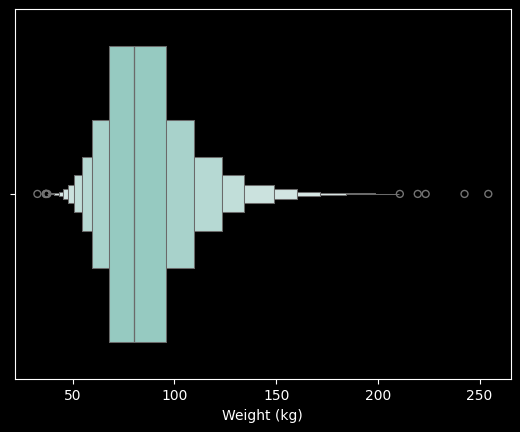

In [30]:
sns.boxenplot(data= df, x = "Weight (kg)")
plt.show()

In [31]:
q1 = df["Weight (kg)"].quantile(0.25)
q3 = df["Weight (kg)"].quantile(0.75)
iqr = q3- q1

In [32]:
q1, q3, iqr

(np.float64(67.6), np.float64(95.8), np.float64(28.200000000000003))

In [33]:
min = q1 - 1.5 * iqr
max = q3 + 1.5 * iqr
min,max

(np.float64(25.29999999999999), np.float64(138.1))

In [34]:
df[(df ["Weight (kg)"] < min) | (df["Weight (kg)"] > max)]

,Unnamed: 0,Weight (kg),Standing Height (cm),BMI(kg/m**2)
34,34,138.2,172.9,46.2
36,36,138.7,158.7,55.1
86,86,143.4,182.0,43.3
94,94,191.4,175.8,61.9
100,100,140.4,175.9,45.4
...,...,...,...,...
8170,8170,166.6,174.7,54.6
8204,8204,143.7,185.4,41.8
8233,8233,173.0,183.6,51.3
8328,8328,144.6,172.8,48.4
